In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [3]:
path = '/kaggle/input/plantvillage-dataset/color'
image_width = 160
image_height = 160
batch_size = 32

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  path,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(image_width, image_height),
  batch_size=batch_size)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


I0000 00:00:1767804708.672065      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767804708.676023      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [41]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  path,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(image_height, image_width),
  batch_size=batch_size)

Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [6]:
class_names = train_ds.class_names
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [7]:
num_classes = len(class_names)
print(num_classes)

38


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [9]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

In [10]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [11]:
IMG_SHAPE = (160,160,3)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
base_model.trainable = False

In [13]:
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

In [15]:
prediction_layer = tf.keras.layers.Dense(num_classes, activation="softmax")

In [16]:
inputs = tf.keras.Input(shape=(160,160,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [17]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
base_learning_rate = 0.0001
model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
initial_epochs = 10

In [20]:
history = model.fit(train_ds,
                    epochs=initial_epochs,
                    validation_data=val_ds)

Epoch 1/10


I0000 00:00:1767804726.967732     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 67s 44ms/step - accuracy: 0.4118 - loss: 2.3194 - val_accuracy: 0.8386 - val_loss: 0.6745
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 54s 39ms/step - accuracy: 0.8300 - loss: 0.6459 - val_accuracy: 0.8856 - val_loss: 0.4347
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - accuracy: 0.8775 - loss: 0.4436 - val_accuracy: 0.9048 - val_loss: 0.3444
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - accuracy: 0.8968 - loss: 0.3596 - val_accuracy: 0.9141 - val_loss: 0.2996
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - accuracy: 0.9088 - loss: 0.3081 - val_accuracy: 0.9196 - val_loss: 0.2729
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - accuracy: 0.9149 - loss: 0.2787 - val_accuracy: 0.9239 - val_loss: 0.2511
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - accuracy: 0.9189 - loss: 0.2628 - val_accuracy: 0.9283 - val_loss: 0.2384
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - accuracy: 0.9276 - loss: 0.23

In [21]:
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

print("Final Training Accuracy:", train_acc[-1])
print("Final Validation Accuracy:", val_acc[-1])

Final Training Accuracy: 0.9336156845092773
Final Validation Accuracy: 0.9360095858573914


In [22]:
loss = history.history['loss']
val_loss = history.history['val_loss']
print("Final Training Loss : " , loss[-1])
print("Final Validation Loss: ", val_loss[-1])

Final Training Loss :  0.21493548154830933
Final Validation Loss:  0.20910421013832092


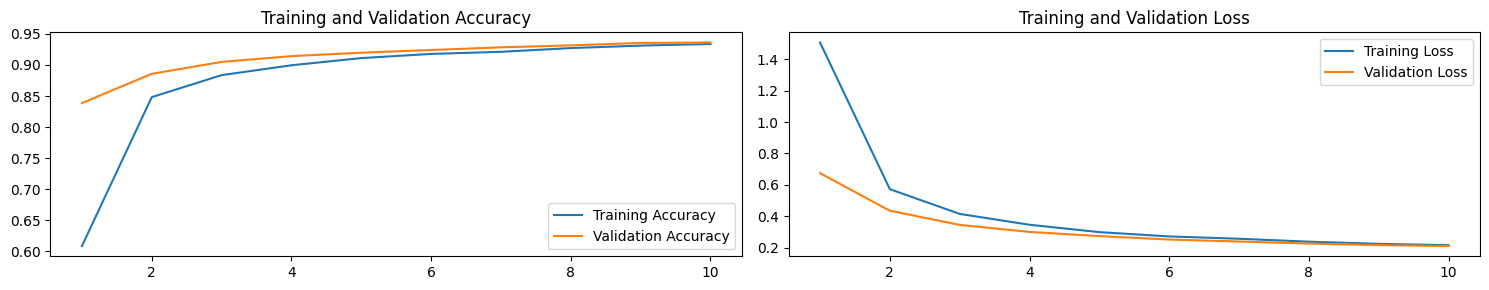

In [23]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(1,11)

plt.figure(figsize=(15, 3))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.tight_layout()
plt.show()

In [24]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch, verbose=0)

    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(preds,axis=1))

In [27]:
from sklearn.metrics import classification_report 

print(classification_report(y_true, y_pred, target_names = val_ds.class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.83      0.88       120
                                 Apple___Black_rot       0.96      0.98      0.97       124
                          Apple___Cedar_apple_rust       0.93      0.95      0.94        56
                                   Apple___healthy       0.96      0.98      0.97       348
                               Blueberry___healthy       0.97      0.99      0.98       318
          Cherry_(including_sour)___Powdery_mildew       0.99      0.93      0.96       208
                 Cherry_(including_sour)___healthy       0.96      0.99      0.98       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.76      0.84       109
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Northern_Leaf_Blight       0.88      0.95      0.

In [31]:
base_model.trainable = True
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [32]:
base_learning_rate = 0.0001
model.compile(
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 1,910,118 (7.29 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [36]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_ds,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=val_ds)

Epoch 11/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 92s 60ms/step - accuracy: 0.7801 - loss: 0.7820 - val_accuracy: 0.9215 - val_loss: 0.2341
Epoch 12/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.9328 - loss: 0.2092 - val_accuracy: 0.9483 - val_loss: 0.1580
Epoch 13/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.9503 - loss: 0.1522 - val_accuracy: 0.9594 - val_loss: 0.1253
Epoch 14/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.9591 - loss: 0.1239 - val_accuracy: 0.9652 - val_loss: 0.1051
Epoch 15/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 59ms/step - accuracy: 0.9633 - loss: 0.1110 - val_accuracy: 0.9689 - val_loss: 0.0958
Epoch 16/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 59ms/step - accuracy: 0.9699 - loss: 0.0908 - val_accuracy: 0.9703 - val_loss: 0.0902
Epoch 17/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.9748 - loss: 0.0806 - val_accuracy: 0.9748 - val_loss: 0.0807
Epoch 18/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 

In [37]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

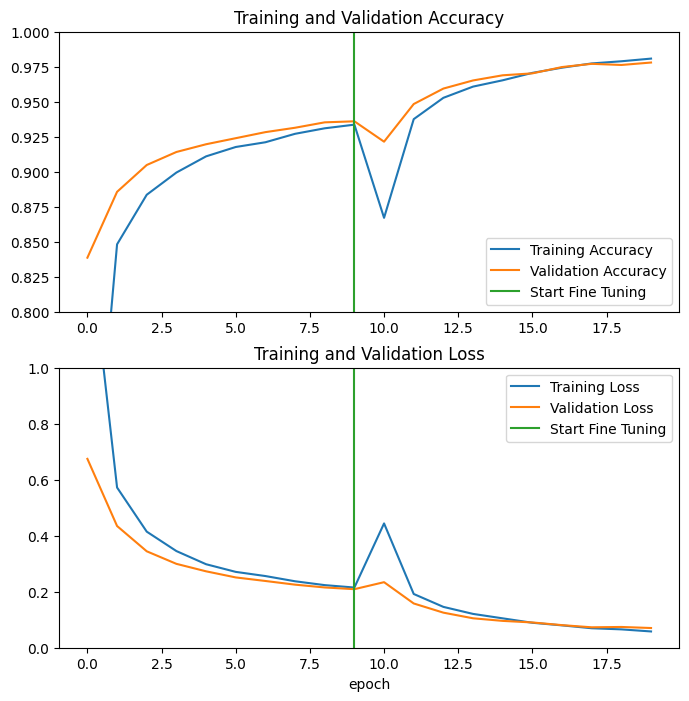

In [38]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [39]:
print("Final Training Accuracy:", acc[-1])
print("Final Validation Accuracy:", val_acc[-1])

Final Training Accuracy: 0.9808028936386108
Final Validation Accuracy: 0.9779946804046631


In [40]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch, verbose=0)

    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(preds,axis=1))

In [42]:
from sklearn.metrics import classification_report 

print(classification_report(y_true, y_pred, target_names = val_ds.class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.95      0.97       120
                                 Apple___Black_rot       0.98      1.00      0.99       124
                          Apple___Cedar_apple_rust       0.98      0.96      0.97        56
                                   Apple___healthy       0.99      0.99      0.99       348
                               Blueberry___healthy       0.99      1.00      0.99       318
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       208
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.76      0.83       109
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Northern_Leaf_Blight       0.87      0.96      0.